# Visualizing Novel Gene Programs Discovered by GPFinder

This tutorial demonstrates how to visualize and interpret novel gene programs discovered through the GPFinder model's attention-based clustering approach. We'll explore how these data-driven gene programs relate to biological cell types and conditions in the bone marrow dataset.

## What are Novel Gene Programs?

Unlike the curated gene programs used in the Base model (e.g., `GP_IRF1`, `GP_USF1`), these novel programs are:
- **Discovered automatically** from the model's attention patterns to HVG genes
- **Data-driven** rather than based on prior biological knowledge
- **Complementary** to existing curated programs, potentially capturing novel biology

## Analysis Strategy

We will:
1. Load the discovered gene programs from clustering results
2. Calculate gene program scores for each cell using Scanpy
3. Visualize program activity across cell types and biological conditions
4. Identify which programs are enriched in specific cell populations

## Prerequisites
- Completed GPFinder training (script 07)
- Novel gene programs extracted via clustering (script 08)
- Original Zeng dataset with UMAP coordinates

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

## 1. Import Required Libraries

In [2]:
from tqdm.notebook import tqdm

## 2. Load the Dataset

We'll use the original Zeng bone marrow dataset which contains:
- Raw gene expression counts (from `adata.raw.X`)
- Cell type annotations
- Pre-computed UMAP coordinates for visualization

In [ ]:
adata = sc.read_h5ad('path/to/your/folder/07_tutorial_zeng/data/raw/zeng.h5ad')

In [4]:
adata.var = adata.var.set_index('gene_symbols')

### Prepare Gene Identifiers

Set gene symbols as the index for easier gene program score calculation.

In [5]:
adata

AnnData object with n_obs × n_vars = 263159 × 27571
    obs: 'AuthorCellType', 'AuthorCellType_Broad', 'Shannon.Diversity.Normalized', 'nCount_RNA', 'nFeature_RNA', 'Study', 'donor_id', 'Sorting', 'S.Score', 'G2M.Score', 'CyclePhase', 'scrublet_scores', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'cell_type_ontology_term_id', 'Donor_Age_Group', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'HCA_Hay2018', 'Oetjen2018', 'Granja2019', 'Mende2022', 'Setty2019', 'Ainciburu2023', 'HVG_intersect3000', 'nCells_Detected', 'nDatasets_Detected', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'Study_colors', 'citation', 'organism', 'organism_ontology_t

### Inspect Dataset

View the structure of the dataset to confirm it's loaded correctly.

In [6]:
# add age group column

def assign_age_group(stage):
    # Handle named stages first
    if stage == "young adult stage":
        return "18-20"
    if stage == "prime adult stage":
        return "24-60"
    if stage == "late adult stage":
        return "65+"
    
    # Extract numeric age from strings like "29-year-old stage"
    try:
        age = int(stage.split("-")[0])
    except (ValueError, AttributeError):
        return np.nan
    
    # Assign based on numeric age
    if 18 <= age <= 20:
        return "18-20"
    elif 24 <= age <= 60:
        return "24-60"
    elif age >= 65:
        return "65+"
    else:
        return np.nan

# Create harmonized age group column
adata.obs["age_group"] = adata.obs["development_stage"].apply(assign_age_group)

### Add Age Group Metadata

Create harmonized age groups for downstream analysis of age-related gene program changes.
This groups donors into three age categories: young adults (18-20), prime adults (24-60), and older adults (65+).

## 3. Load Discovered Novel Gene Programs

Load the gene programs that were automatically discovered through attention-based clustering in the GPFinder model (from script 08).

Each column in this CSV file represents one discovered gene program (e.g., `gp_0`, `gp_1`, etc.), with genes listed as rows.

In [7]:
adata.X.max()

8.895777

## 4. Calculate Gene Program Scores for Each Cell

Using Scanpy's `score_genes` function, we calculate an activity score for each gene program in each cell. 

**How it works:**
- For each program, the function averages the expression of all genes in that program
- Subtracts a control score (average of randomly selected genes) to account for background
- Higher scores indicate greater activity of that gene program in the cell

**Note:** This may take a few minutes depending on dataset size and number of programs.

In [8]:
tripso_gp = pd.read_csv('output_gpfinder/gpdb_clusters_from_attention.csv')

In [9]:
# Calculate gene program activity scores for all discovered programs
# Each score represents how active a program is in each cell
for gp in tqdm(tripso_gp.columns):
    sc.tl.score_genes(adata, 
                      tripso_gp[gp].dropna().tolist(),  # Genes in this program
                      score_name = f'tripso_{gp}_score', # Store as new obs column
                      use_raw = False                    # Use normalized counts
                     )

  0%|          | 0/3 [00:00<?, ?it/s]

## 5. Visualize Cell Types on UMAP

First, let's visualize the cell type landscape to understand the composition of our dataset.
This provides context for interpreting which gene programs are active in which cell populations.

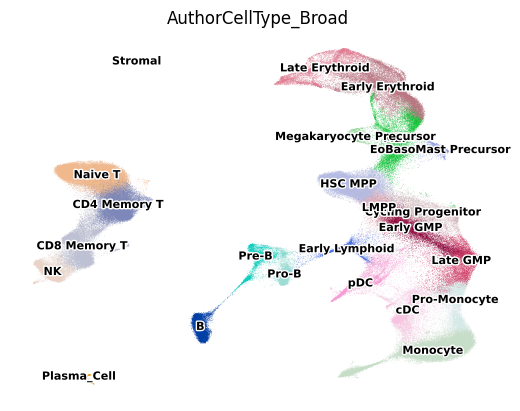

In [10]:
# Visualize cell types on UMAP to understand the cellular landscape
sc.pl.umap(
    adata,
    color = 'AuthorCellType_Broad',  # Broad cell type categories
    frameon = False,
    legend_loc = 'on data',          # Place labels directly on clusters
    legend_fontsize=8, 
    legend_fontoutline=2
)

## 6. Visualize All Novel Gene Program Activities

Now we'll visualize the activity of all discovered gene programs across the UMAP. 

**What to look for:**
- Programs with **cell type-specific** patterns (high in one cluster, low elsewhere)
- Programs with **gradient patterns** across developmental or activation states
- Programs active in **rare populations** that might capture specialized biology

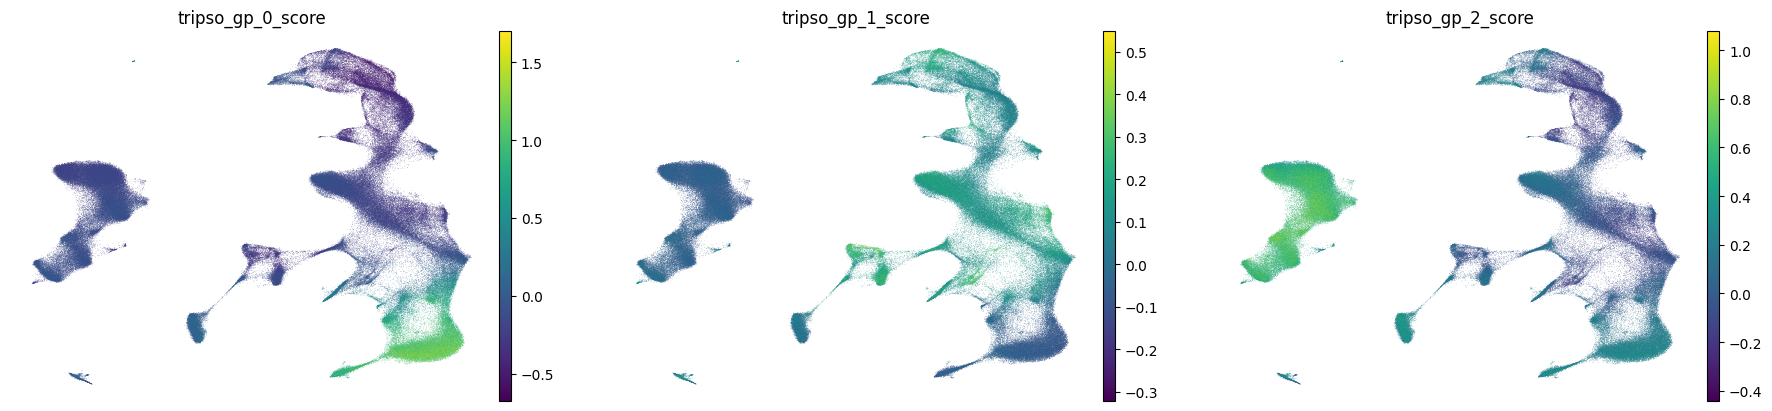

In [11]:
# Visualize activity of all discovered gene programs on UMAP
# Each subplot shows where in the cell landscape a program is active
sc.pl.umap(
    adata,
    color = [f'tripso_{gp}_score' for gp in tripso_gp.columns],  # All GP scores
    frameon = False
)

## 7. Case Study: Age-Related Changes in T/NK Cells

Based on the UMAP, we can see increased gp0 activity in yhe lymphoid cluster. How does gene program `gp_0` vary with age?

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


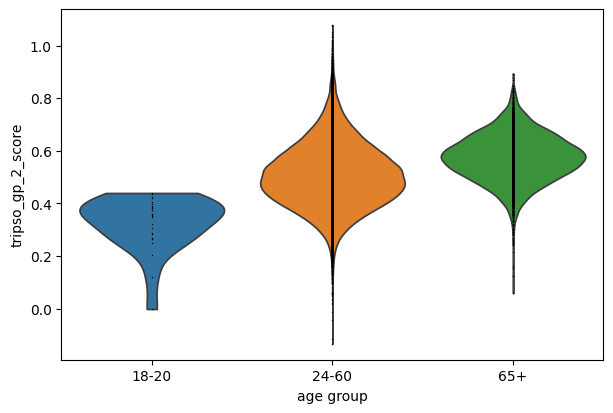

In [12]:
# Compare gp_0 activity across age groups in T and NK cells
# This reveals whether this program changes with aging in these immune populations
sc.pl.violin(
    adata[adata.obs['AuthorCellType_Broad'].isin(['Naive T', 'CD4 Memory T', 'CD8 Memory T', 'NK'])],
    'tripso_gp_2_score',      
    groupby = 'age_group',   
    jitter = False   
)

In [13]:
# check how many genes are in the gene program
len(tripso_gp['gp_0'].dropna())

100

## 7.2 Variation in invidiual genes

We see a trend a in `gp0` score with increasing age. We can than examine which genes contribute to this pattern by examining which genes have higher attention scores in this GP. 

In [14]:
# Here, we will load all data splits to ensure we have enough cells from younger group
attn1 = sc.read_h5ad('output_gpfinder/attention/HVG_attention_train_set.h5ad')
attn2 = sc.read_h5ad('output_gpfinder/attention/HVG_attention_val_set.h5ad')
attn3 = sc.read_h5ad('output_gpfinder/attention/HVG_attention_test_set.h5ad')
attn = ad.concat([attn1, attn2, attn3])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [15]:
# We subset to our cell population of interest
# and focus on the genes from gp 0

attn_lymphoid = attn[attn.obs['AuthorCellType_Broad'].isin(['Naive T', 'CD4 Memory T', 'CD8 Memory T', 'NK'])]

attn_lymphoid = attn_lymphoid[:, attn_lymphoid.var.index.isin(tripso_gp['gp_2'].dropna().values)]

In [16]:
sc.tl.rank_genes_groups(attn_lymphoid, groupby = 'age_group')

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [17]:
# extract a dataframe with genes which have higher attention in older age groups
old = sc.get.rank_genes_groups_df(
    attn_lymphoid, 
    group = '65+'
)

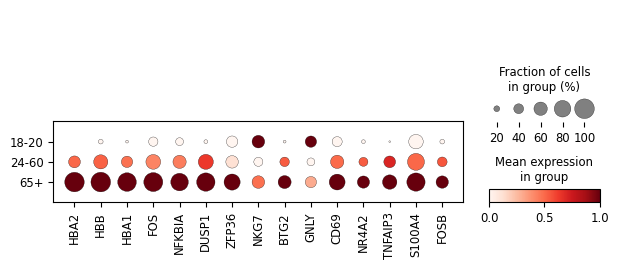

In [18]:
# and visualize their expression in the original gene expression space
sc.pl.dotplot(
    adata[adata.obs['AuthorCellType_Broad'].isin(['Naive T', 'CD4 Memory T', 'CD8 Memory T', 'NK'])],
    old['names'][:15],
    groupby = 'age_group',
    standard_scale = 'var',
    use_raw = False
)

FOS, FOSB NFKBIA and TNFAIP3 are all involved in inflammatory processes, consistent with the known increase in inflammation with age known as "inflammaging" (reviewed in [Shchukina 2023](https://www.sciencedirect.com/science/article/pii/S1044532323001094)). Hemoglobin genes have also recently been reported as playing a role in T cell mitochondrial activity and activation ([Reed et al, 2025](https://pmc.ncbi.nlm.nih.gov/articles/PMC12324427/)). Therefore, it is possible that `gp2` may represent a coordinated shift in T cell inflammation and metabolism with age. 